In [4]:
import numpy as np
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score


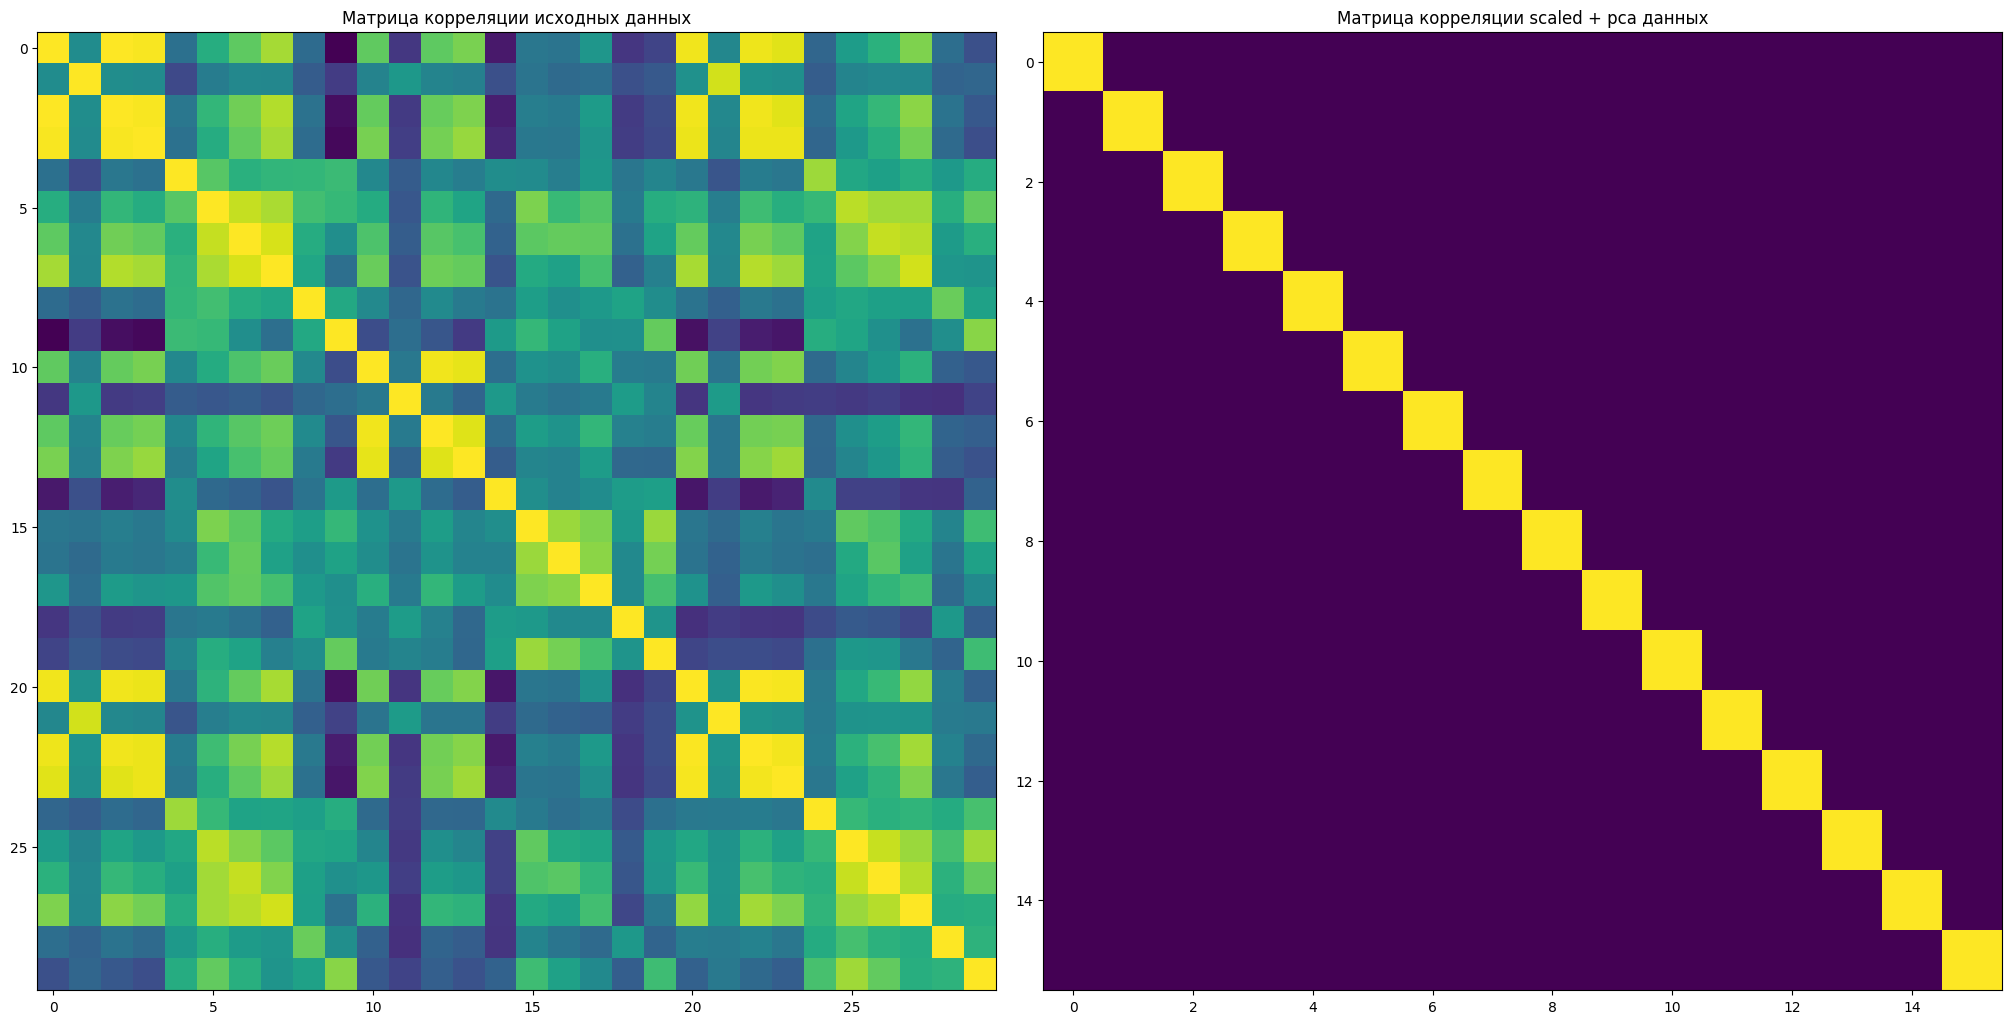

In [34]:
def normalize_features(X):
    # Standardize features to mean=0, std=1
    X_normalized = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    return X_normalized

def clean_up_data(X):
    #for PCA (feature engineering)
    from sklearn.decomposition import PCA

    #for data scaling
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_drop = np.delete(X_scaled, [2, 3, 12, 13, 22, 23], axis=1)
    pca = PCA(n_components=0.99)
    x_pca = pca.fit_transform(X_scaled_drop)

    return x_pca

X = load_breast_cancer(return_X_y=True)[0]
X_norm = clean_up_data(X)
y = load_breast_cancer(return_X_y=True)[1]

s = (len(X_norm) // 5)

X_train = np.array(X_norm[s:])
X_train_with_b = np.c_[X_train, np.ones(X_train.shape[0])]

y_train = np.array(y[s:])
y_train[y_train == 0] = -1

X_test = np.array(X_norm[:s])
X_test_with_b = np.c_[X_test, np.ones(X_test.shape[0])]
y_test = np.array(y[:s])
y_test[y_test == 0] = -1


fig, (ax1, ax2) = plt.subplots(1, 2, layout='constrained', figsize=(20, 10))
ax1.imshow(np.corrcoef(X, rowvar=False))
ax1.set_title('Матрица корреляции исходных данных')
ax2.imshow(np.corrcoef(X_norm, rowvar=False))
ax2.set_title('Матрица корреляции scaled + pca данных')

X_train.shape, y_train.shape, X_test.shape, y_test.shape

plt.show()

## SVM решение прямой задачи

$y_i(w^Tx_i + b) \ge 1$

$L(w, b) = \dfrac{1}{2}||w||^2_2 + C \sum \max(0, 1 - y_i(w^Tx_i + b))$

вместо отдельного параметра b в $w^Tx + b$ добавим колонку в $w$ и дополним $x$ колонкой из единиц:

$w^Tx + b = w'^Tx'$ where $w' = [b|w], x' = [1|x]$

if $y_i(w^Tx_i) \ge 1$ :

$L(w)' = w$

if $y_i(w^Tx_i) < 1$ :

$L(w)' = w - C\sum y_i x_i$



0.8414889861266164


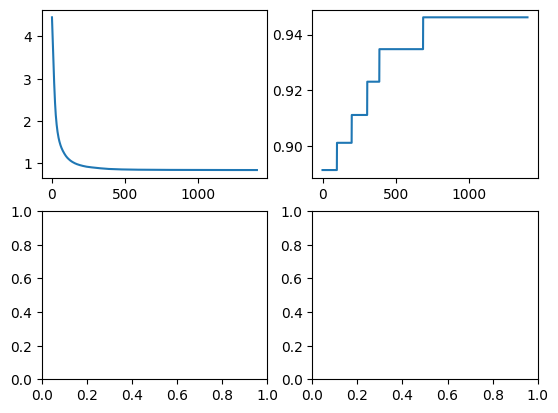

In [235]:


def primal(y, X, w, C, step, iters, tol):
    def accuracy(y, X, w):
        idxs = np.sign(np.dot(X, w))
        res = 0
        for i in range(y.shape[0]):
            if y[i] == idxs[i]:
                res += 1
        return (f1_score(y, idxs), res/y.shape[0])

    hist_H = []
    hist_w = []
    hist_accuracy = []
    w = w.copy()
    for _ in range(iters):
        gradw = w.copy()
        for i in range(X.shape[0]):
            L = y[i] * np.dot(X[i], w)
            if L < 1:
                gradw -= C * X[i] * y[i]
        w -= step * gradw
        margins = y * np.dot(X, w)
        hinge_loss = np.maximum(0, 1 - margins)
        H = 0.5 * np.linalg.norm(w)**2 + C * np.sum(hinge_loss)
        hist_w.append(np.linalg.norm(w))
        hist_H.append(H)
        hist_accuracy.append(accuracy(y_test, X_test_with_b, w)[0])
        if (len(hist_H) > 1 and np.abs(hist_H[-2]-hist_H[-1]) < tol):
            break


    return w, hist_H, hist_w, hist_accuracy

C = 0.01
STEP = 0.001
ITERS = 10000
TOL = 1e-8
w = np.zeros(X_train_with_b.shape[1])
w_star, hist_obj, hist_w, hist_accuracy = primal(y_train, X_train_with_b, w.copy(), C, STEP, ITERS, TOL)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)
ax1.plot(hist_obj)
ax2.plot(hist_accuracy)
print(hist_obj[-1])
plt.show()

Training Nesterov...
Training Standard GD...

Comparison Results (Linear Kernel):
Nesterov - F1: 0.9213, Accuracy: 0.9381
Standard GD - F1: 0.9333, Accuracy: 0.9469
Nesterov converged in 5000 iterations
Standard GD converged in 5000 iterations


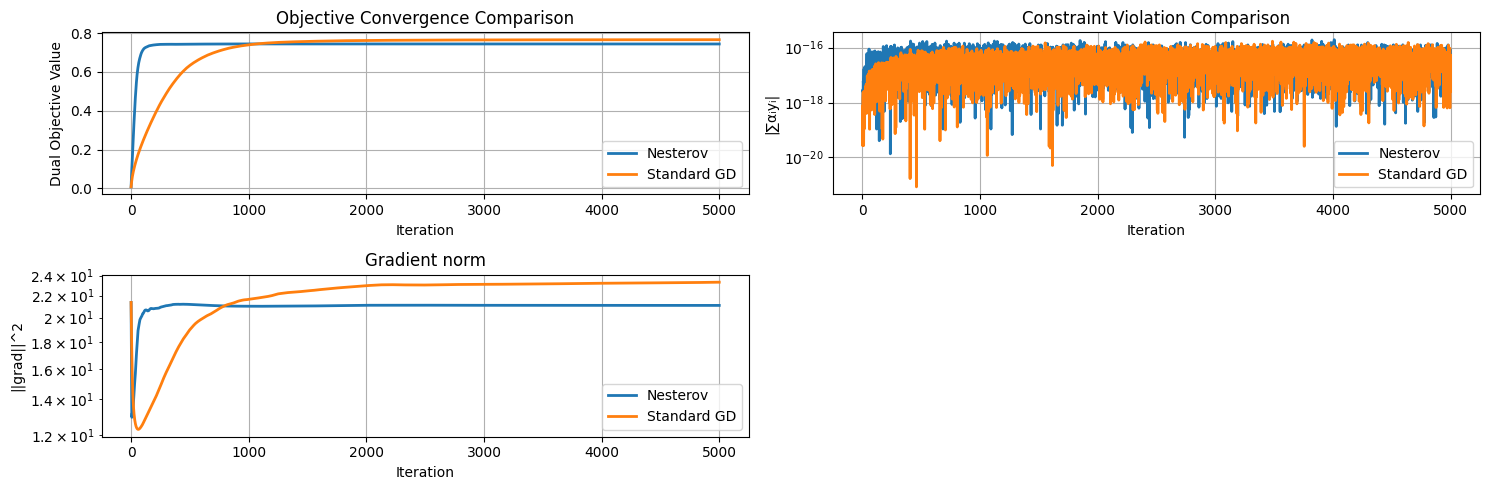

In [239]:
def accuracyz(y, X, w):
    idxs = np.sign(np.dot(X, w))
    if (0 in idxs):
        return (0, 0)
    res = 0
    for i in range(y.shape[0]):
        if y[i] == idxs[i]:
            res += 1
    # print(idxs[:10], y[:20], y[-20:], y.shape, X.shape, w.shape, idxs.shape, res)
    return (f1_score(y, idxs), res/y.shape[0])

def dual_accuracy(a):
    w_dual = np.sum(a[:, np.newaxis] * y_train[:, np.newaxis] * X_train, axis=0)
    return accuracyz(y_test, X_test, w_dual)

class ProjectionGD:
    def compute_kernel_matrix(self, X):
        """Compute linear kernel matrix: K_ij = x_i · x_j"""
        return X @ X.T
    
    def compute_gradient(self, alpha, K, y):
        """Gradient of dual SVM objective: ∇L(α) = 1 - (K ⊙ yyᵀ)α"""
        Y = np.diag(y)  # Create diagonal matrix from y
        return np.ones(len(y)) - Y @ K @ Y @ alpha
    
    def compute_objective(self, alpha, K, y):
        """Dual objective: L(α) = ∑αᵢ - ½ αᵀ(K ⊙ yyᵀ)α (MAXIMIZATION)"""
        return np.sum(alpha) - 0.5 * alpha.T @ ((K * np.outer(y, y)) @ alpha)

    
    def project_to_constraints(self, alpha, y):
        """More robust projection"""
        n = len(alpha)
        alpha = np.clip(alpha, 0, self.C)
        sum_alpha_y = np.dot(alpha, y)
        
        if abs(sum_alpha_y) < 1e-12:
            return alpha
        
        # Use iterative projection for better numerical stability
        max_proj_iter = 100
        alpha_proj = alpha.copy()
        
        for proj_iter in range(max_proj_iter):
            sum_violation = np.dot(alpha_proj, y)
            if abs(sum_violation) < 1e-12:
                break
                
            # Find the most adjustable variables
            if sum_violation > 0:
                can_decrease = (y > 0) & (alpha_proj > 0)
                can_increase = (y < 0) & (alpha_proj < self.C)
            else:
                can_increase = (y > 0) & (alpha_proj < self.C)
                can_decrease = (y < 0) & (alpha_proj > 0)
            
            total_capacity = (np.sum(can_decrease * np.abs(y)) + 
                            np.sum(can_increase * np.abs(y)))
            
            if total_capacity < 1e-12:
                break
                
            adjustment = sum_violation / total_capacity
            
            if sum_violation > 0:
                alpha_proj[can_decrease] -= adjustment * y[can_decrease]
                alpha_proj[can_increase] -= adjustment * y[can_increase]
            else:
                alpha_proj[can_increase] -= adjustment * y[can_increase]
                alpha_proj[can_decrease] -= adjustment * y[can_decrease]
            
            alpha_proj = np.clip(alpha_proj, 0, self.C)
        
        return alpha_proj

class LinearNesterovDualSVM(ProjectionGD):
    def __init__(self, C=1.0, max_iter=1000, learning_rate=0.01, momentum=0.9, tol=1e-4):
        self.C = C
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.tol = tol
        
        self.alpha = None
        self.support_vectors_ = None
        self.support_vector_labels_ = None
        self.X_train = None
        self.y_train = None

        self.grad_history = []

    def fit(self, X, y):
        """Fit linear SVM using Nesterov accelerated gradient"""
        # Ensure labels are ±1
        y = np.where(y == 0, -1, y)
        
        self.X_train = X.copy()
        self.y_train = y.copy()
        
        n_samples = X.shape[0]
        K = self.compute_kernel_matrix(X)
        
        # Initialize
        alpha = np.zeros(n_samples)
        v = np.zeros(n_samples)  # velocity term
        
        objective_history = []
        constraint_violation_history = []

        for iteration in range(self.max_iter):
            # Nesterov lookahead
            alpha_lookahead = alpha + self.momentum * v
            
            # Compute gradient at lookahead position
            grad = self.compute_gradient(alpha_lookahead, K, y)

            self.grad_history.append(np.linalg.norm(grad))
            # Update velocity and parameters
            v = self.momentum * v + self.learning_rate * grad
            alpha_new = alpha + v
            
            # Project to constraints
            alpha_new = self.project_to_constraints(alpha_new, y)
            
            # Track convergence metrics
            obj_val = self.compute_objective(alpha_new, K, y)
            objective_history.append(obj_val)
            
            constraint_violation = abs(np.dot(alpha_new, y))
            constraint_violation_history.append(constraint_violation)
            
            # Check convergence
            if iteration > 10:
                if np.linalg.norm(grad) < self.tol:
                    break
            
            alpha = alpha_new
        
        self.alpha = alpha
        
        # Store support vectors
        sv_indices = self.alpha > 1e-5
        self.support_vectors_ = X[sv_indices]
        self.support_vector_labels_ = y[sv_indices]
        self.alpha_sv = self.alpha[sv_indices]
        
        return objective_history, constraint_violation_history

class StandardGradientDescentDualSVM(ProjectionGD):
    """Standard Gradient Descent for comparison"""
    def __init__(self, C=1.0, max_iter=1000, learning_rate=0.01, tol=1e-4):
        self.C = C
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.tol = tol
        
        self.alpha = None
        self.support_vectors_ = None
        self.support_vector_labels_ = None
        self.X_train = None
        self.y_train = None

        self.grad_history = []

    def fit(self, X, y):
        y = np.where(y == 0, -1, y)
        self.X_train = X.copy()
        self.y_train = y.copy()
        
        n_samples = X.shape[0]
        K = self.compute_kernel_matrix(X)
        
        alpha = np.zeros(n_samples)
        objective_history = []
        constraint_violation_history = []
        
        for iteration in range(self.max_iter):
            # Standard gradient update (no momentum)
            grad = self.compute_gradient(alpha, K, y)
            self.grad_history.append(np.linalg.norm(grad))
            alpha_new = alpha + self.learning_rate * grad
            alpha_new = self.project_to_constraints(alpha_new, y)
            
            # Track metrics
            obj_val = self.compute_objective(alpha_new, K, y)
            objective_history.append(obj_val)
            
            constraint_violation = abs(np.dot(alpha_new, y))
            constraint_violation_history.append(constraint_violation)
            
            # Check convergence
            if iteration > 10:
                if np.linalg.norm(grad) < self.tol:
                    break
            
            alpha = alpha_new
        
        self.alpha = alpha
        
        # Store support vectors
        sv_indices = self.alpha > 1e-5
        self.support_vectors_ = X[sv_indices]
        self.support_vector_labels_ = y[sv_indices]
        self.alpha_sv = self.alpha[sv_indices]
        
        return objective_history, constraint_violation_history

# Demonstration functions using your existing data
def demonstrate_linear_svm():
    """Demonstrate Linear Dual SVM with Nesterov acceleration using your data"""
    
    print("Training Linear Dual SVM with Nesterov Acceleration...")
    svm = LinearNesterovDualSVM(C=0.1, max_iter=1000, learning_rate=0.0001, momentum=0.9)
    objective_history, constraint_history = svm.fit(X_train, y_train)
    
    # Evaluate using your dual_accuracy function
    f1_score, accuracy = dual_accuracy(svm.alpha)
    
    print(f"Test F1 Score: {f1_score:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Number of support vectors: {len(svm.support_vectors_)}")
    print(f"Final constraint violation: {constraint_history[-1]:.2e}")
    
    # Plot results
    plt.figure(figsize=(15, 5))
    
    # Plot convergence
    plt.subplot(1, 3, 1)
    plt.plot(objective_history)
    plt.title('Nesterov: Objective Convergence')
    plt.xlabel('Iteration')
    plt.ylabel('Dual Objective Value')
    plt.grid(True)
    
    # Plot constraint violation
    plt.subplot(1, 3, 2)
    plt.semilogy(constraint_history)
    plt.title('Nesterov: Constraint Violation')
    plt.xlabel('Iteration')
    plt.ylabel('|∑αᵢyᵢ|')
    plt.grid(True)
    
    return svm, f1_score, accuracy

def compare_linear_methods(nesterov_svm, standard_svm):
    """Compare Nesterov vs Standard GD for linear SVM using your data"""
    
    # Nesterov acceleration
    print("Training Nesterov...")
    nesterov_obj, nesterov_constraint = nesterov_svm.fit(X_train, y_train)
    
    # Standard gradient descent
    print("Training Standard GD...")
    standard_obj, standard_constraint = standard_svm.fit(X_train, y_train)
    
    # Compare performance using your dual_accuracy function
    nesterov_f1, nesterov_acc = dual_accuracy(nesterov_svm.alpha)
    standard_f1, standard_acc = dual_accuracy(standard_svm.alpha)
    
    print(f"\nComparison Results (Linear Kernel):")
    print(f"Nesterov - F1: {nesterov_f1:.4f}, Accuracy: {nesterov_acc:.4f}")
    print(f"Standard GD - F1: {standard_f1:.4f}, Accuracy: {standard_acc:.4f}")
    print(f"Nesterov converged in {len(nesterov_obj)} iterations")
    print(f"Standard GD converged in {len(standard_obj)} iterations")
    
    # Plot convergence comparison
    plt.figure(figsize=(15, 5))
    
    plt.subplot(2, 2, 1)
    plt.plot(nesterov_obj, label='Nesterov', linewidth=2)
    plt.plot(standard_obj, label='Standard GD', linewidth=2)
    plt.title('Objective Convergence Comparison')
    plt.xlabel('Iteration')
    plt.ylabel('Dual Objective Value')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(2, 2, 2)
    plt.semilogy(nesterov_constraint, label='Nesterov', linewidth=2)
    plt.semilogy(standard_constraint, label='Standard GD', linewidth=2)
    plt.title('Constraint Violation Comparison')
    plt.xlabel('Iteration')
    plt.ylabel('|∑αᵢyᵢ|')
    plt.legend()
    plt.grid(True)
    
    # Plot support vectors comparison
    # plt.subplot(2, 3, 3)
    # methods = ['Nesterov', 'Standard GD']
    # sv_counts = [len(nesterov_svm.support_vectors_), len(standard_svm.support_vectors_)]
    # plt.bar(methods, sv_counts)
    # plt.title('Number of Support Vectors')
    # plt.ylabel('Count')

    plt.subplot(2, 2, 3)
    plt.semilogy(nesterov_svm.grad_history, label='Nesterov', linewidth=2)
    plt.semilogy(standard_svm.grad_history, label='Standard GD', linewidth=2)
    plt.title('Gradient norm')
    plt.xlabel('Iteration')
    plt.ylabel('||grad||^2')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return nesterov_svm, standard_svm

def tune_linear_svm_nesterov():
    """Simple hyperparameter tuning for linear SVM using your data"""
    
    best_f1 = 0
    best_accuracy = 0
    best_params = {}
    
    # Grid search over C and learning rate
    for C in [0.01, 0.1, 1.0, 10.0]:
        for lr in [1e-6, 1e-5, 1e-4, 1e-3]:
            # print(f"Testing C={C}, lr={lr}")
            svm = LinearNesterovDualSVM(C=C, learning_rate=lr, momentum=0.9, max_iter=500, tol=1e-8)
            svm.fit(X_train, y_train)
            f1_score, accuracy = dual_accuracy(svm.alpha)
            
            if f1_score > best_f1:
                best_f1 = f1_score
                best_accuracy = accuracy
                best_params = {'C': C, 'learning_rate': lr}
    
    print(f"\nHyperparameter Tuning Results:")
    print(f"Best F1 Score: {best_f1:.4f}")
    print(f"Best Accuracy: {best_accuracy:.4f}")
    print(f"Best Parameters: {best_params}")
    
    return best_f1, best_accuracy, best_params

def tune_linear_svm_std():
    """Simple hyperparameter tuning for linear SVM using your data"""
    
    best_f1 = 0
    best_accuracy = 0
    best_params = {}
    
    # Grid search over C and learning rate
    for C in [0.01, 0.1, 1.0, 10.0]:
        for lr in [1e-5, 1e-4, 1e-3]:
            # print(f"Testing C={C}, lr={lr}")
            svm = StandardGradientDescentDualSVM(C=C, learning_rate=lr, max_iter=500, tol=1e-8)
            svm.fit(X_train, y_train)
            f1_score, accuracy = dual_accuracy(svm.alpha)
            
            if f1_score > best_f1:
                best_f1 = f1_score
                best_accuracy = accuracy
                best_params = {'C': C, 'learning_rate': lr}
    
    print(f"\nHyperparameter Tuning Results:")
    print(f"Best F1 Score: {best_f1:.4f}")
    print(f"Best Accuracy: {best_accuracy:.4f}")
    print(f"Best Parameters: {best_params}")
    
    return best_f1, best_accuracy, best_params

# print("=" * 60)
# svm, f1, acc = demonstrate_linear_svm()

print("=" * 60)
compare_linear_methods(
    LinearNesterovDualSVM(C=0.01, max_iter=5000, learning_rate=0.00002, momentum=0.9),
    StandardGradientDescentDualSVM(C=0.01, max_iter=5000, learning_rate=0.00002)
)

print("=" * 60)
# best_f1, best_acc, best_params = tune_linear_svm_nesterov()
# best_f1, best_acc, best_params = tune_linear_svm_std()

Training Nesterov...
Training Standard GD...

Comparison Results (Linear Kernel):
Nesterov - F1: 0.9451, Accuracy: 0.9558
Standard GD - F1: 0.9333, Accuracy: 0.9469
Nesterov converged in 3000 iterations
Standard GD converged in 3000 iterations


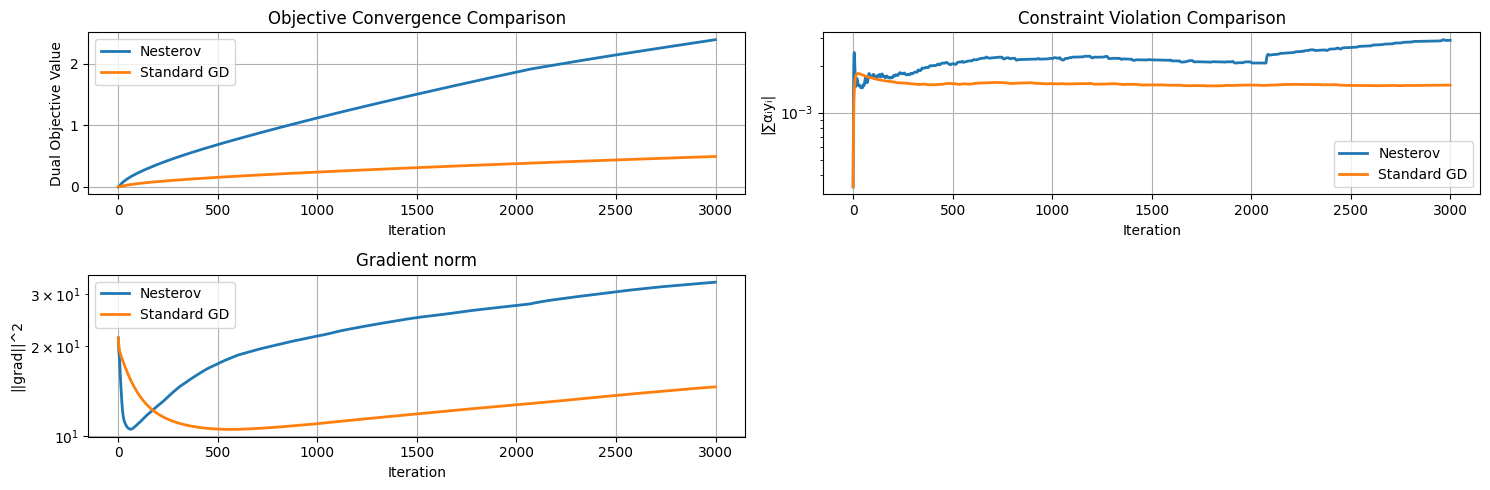

(<__main__.NesterovPenalty at 0x28f782a50>,
 <__main__.StandardGDPenalty at 0x28f781940>)

In [229]:
class PenaltyGD:
    def compute_kernel_matrix(self, X):
        """Compute linear kernel matrix: K_ij = x_i · x_j"""
        return X @ X.T
    
    def compute_gradient(self, alpha, K, y):
        Y = np.diag(y)  # Create diagonal matrix from y
        return np.ones(len(y)) - Y @ K @ Y @ alpha - 200 * y * np.dot(y, alpha)
    
    def compute_objective(self, alpha, K, y):
        """Dual objective (MAXIMIZATION)"""
        return np.sum(alpha) - 0.5 * alpha.T @ ((K * np.outer(y, y)) @ alpha) - 100 * np.dot(y, alpha)**2

class NesterovPenalty(PenaltyGD):
    def __init__(self, C=1.0, max_iter=1000, learning_rate=0.01, momentum=0.9, tol=1e-4):
        self.C = C
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.tol = tol
        
        self.alpha = None
        self.support_vectors_ = None
        self.support_vector_labels_ = None
        self.X_train = None
        self.y_train = None

        self.grad_history = []

    def fit(self, X, y):
        """Fit linear SVM using Nesterov accelerated gradient"""
        # Ensure labels are ±1
        y = np.where(y == 0, -1, y)
        
        self.X_train = X.copy()
        self.y_train = y.copy()
        
        n_samples = X.shape[0]
        K = self.compute_kernel_matrix(X)
        
        # Initialize
        alpha = np.zeros(n_samples)
        v = np.zeros(n_samples)  # velocity term
        
        objective_history = []
        constraint_violation_history = []

        for iteration in range(self.max_iter):
            # Nesterov lookahead
            alpha_lookahead = alpha + self.momentum * v
            
            # Compute gradient at lookahead position
            grad = self.compute_gradient(alpha_lookahead, K, y)

            self.grad_history.append(np.linalg.norm(grad))
            # Update velocity and parameters
            v = self.momentum * v + self.learning_rate * grad
            alpha_new = alpha + v

            # need to enforce box constraints [0, C]
            alpha_new = np.clip(alpha_new, 0, self.C)
            # Track convergence metrics
            obj_val = self.compute_objective(alpha_new, K, y)
            objective_history.append(obj_val)
            
            constraint_violation = abs(np.dot(alpha_new, y))
            constraint_violation_history.append(constraint_violation)
            
            # Check convergence
            if iteration > 10:
                # rel_change = abs(objective_history[-1] - objective_history[-2])
                # if rel_change < self.tol and constraint_violation < 1e-6:
                #     # print(f"Converged after {iteration} iterations")
                #     break
                if np.linalg.norm(grad) < self.tol:
                    break
            
            alpha = alpha_new
        
        self.alpha = alpha
        
        # Store support vectors
        sv_indices = self.alpha > 1e-5
        self.support_vectors_ = X[sv_indices]
        self.support_vector_labels_ = y[sv_indices]
        self.alpha_sv = self.alpha[sv_indices]
        
        return objective_history, constraint_violation_history

class StandardGDPenalty(PenaltyGD):
    """Standard Gradient Descent for comparison"""
    def __init__(self, C=1.0, max_iter=1000, learning_rate=0.01, tol=1e-4):
        self.C = C
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.tol = tol
        
        self.alpha = None
        self.support_vectors_ = None
        self.support_vector_labels_ = None
        self.X_train = None
        self.y_train = None

        self.grad_history = []

    def fit(self, X, y):
        y = np.where(y == 0, -1, y)
        self.X_train = X.copy()
        self.y_train = y.copy()
        
        n_samples = X.shape[0]
        K = self.compute_kernel_matrix(X)
        
        alpha = np.zeros(n_samples)
        objective_history = []
        constraint_violation_history = []
        
        for iteration in range(self.max_iter):
            # Standard gradient update (no momentum)
            grad = self.compute_gradient(alpha, K, y)
            self.grad_history.append(np.linalg.norm(grad))
            alpha_new = alpha + self.learning_rate * grad
            # need to enforce box constraints [0, C]
            alpha_new = np.clip(alpha_new, 0, self.C)
            
            # Track metrics
            obj_val = self.compute_objective(alpha_new, K, y)
            objective_history.append(obj_val)
            
            constraint_violation = abs(np.dot(alpha_new, y))
            constraint_violation_history.append(constraint_violation)
            
            # Check convergence
            if iteration > 10:
                # rel_change = abs(objective_history[-1] - objective_history[-2])
                # if rel_change < self.tol and constraint_violation < 1e-6:
                #     # print(f"Converged after {iteration} iterations")
                #     break
                if np.linalg.norm(grad) < self.tol:
                    break
            
            alpha = alpha_new
        
        self.alpha = alpha
        
        # Store support vectors
        sv_indices = self.alpha > 1e-5
        self.support_vectors_ = X[sv_indices]
        self.support_vector_labels_ = y[sv_indices]
        self.alpha_sv = self.alpha[sv_indices]
        
        return objective_history, constraint_violation_history

compare_linear_methods(
    NesterovPenalty(C=0.1, max_iter=3000, learning_rate=0.000002, momentum=0.9),
    StandardGDPenalty(C=0.1, max_iter=3000, learning_rate=0.000002)
)

Running Primal SVM...
Running Dual SVM (Nesterov)...
PRIMAL vs DUAL SVM COMPARISON

1. WEIGHT VECTOR COMPARISON:
Primal ||w||: 0.782808
Dual   ||w||: 0.856759
Weight vector cosine similarity: 0.916572

2. OBJECTIVE VALUE COMPARISON:
Primal objective: 0.843616
Dual objective:   0.744140
Duality gap:      0.099475

3. PREDICTION PERFORMANCE:
Training accuracy - Primal: 0.9803, Dual: 0.9715
Test accuracy     - Primal: 0.9558, Dual: 0.9381

4. SUPPORT VECTORS:
Primal SV count: 121
Dual SV count:   205
Support vector overlap: 105 points

5. KKT CONDITIONS CHECK (Dual):
Stationarity violation: 0.00e+00
Complementary slackness violation: 2.71e+02

6. CONSTRAINT SATISFACTION:
Dual constraint ∑αᵢyᵢ = 0 violation: 9.66e-17
Box constraint violations: 0


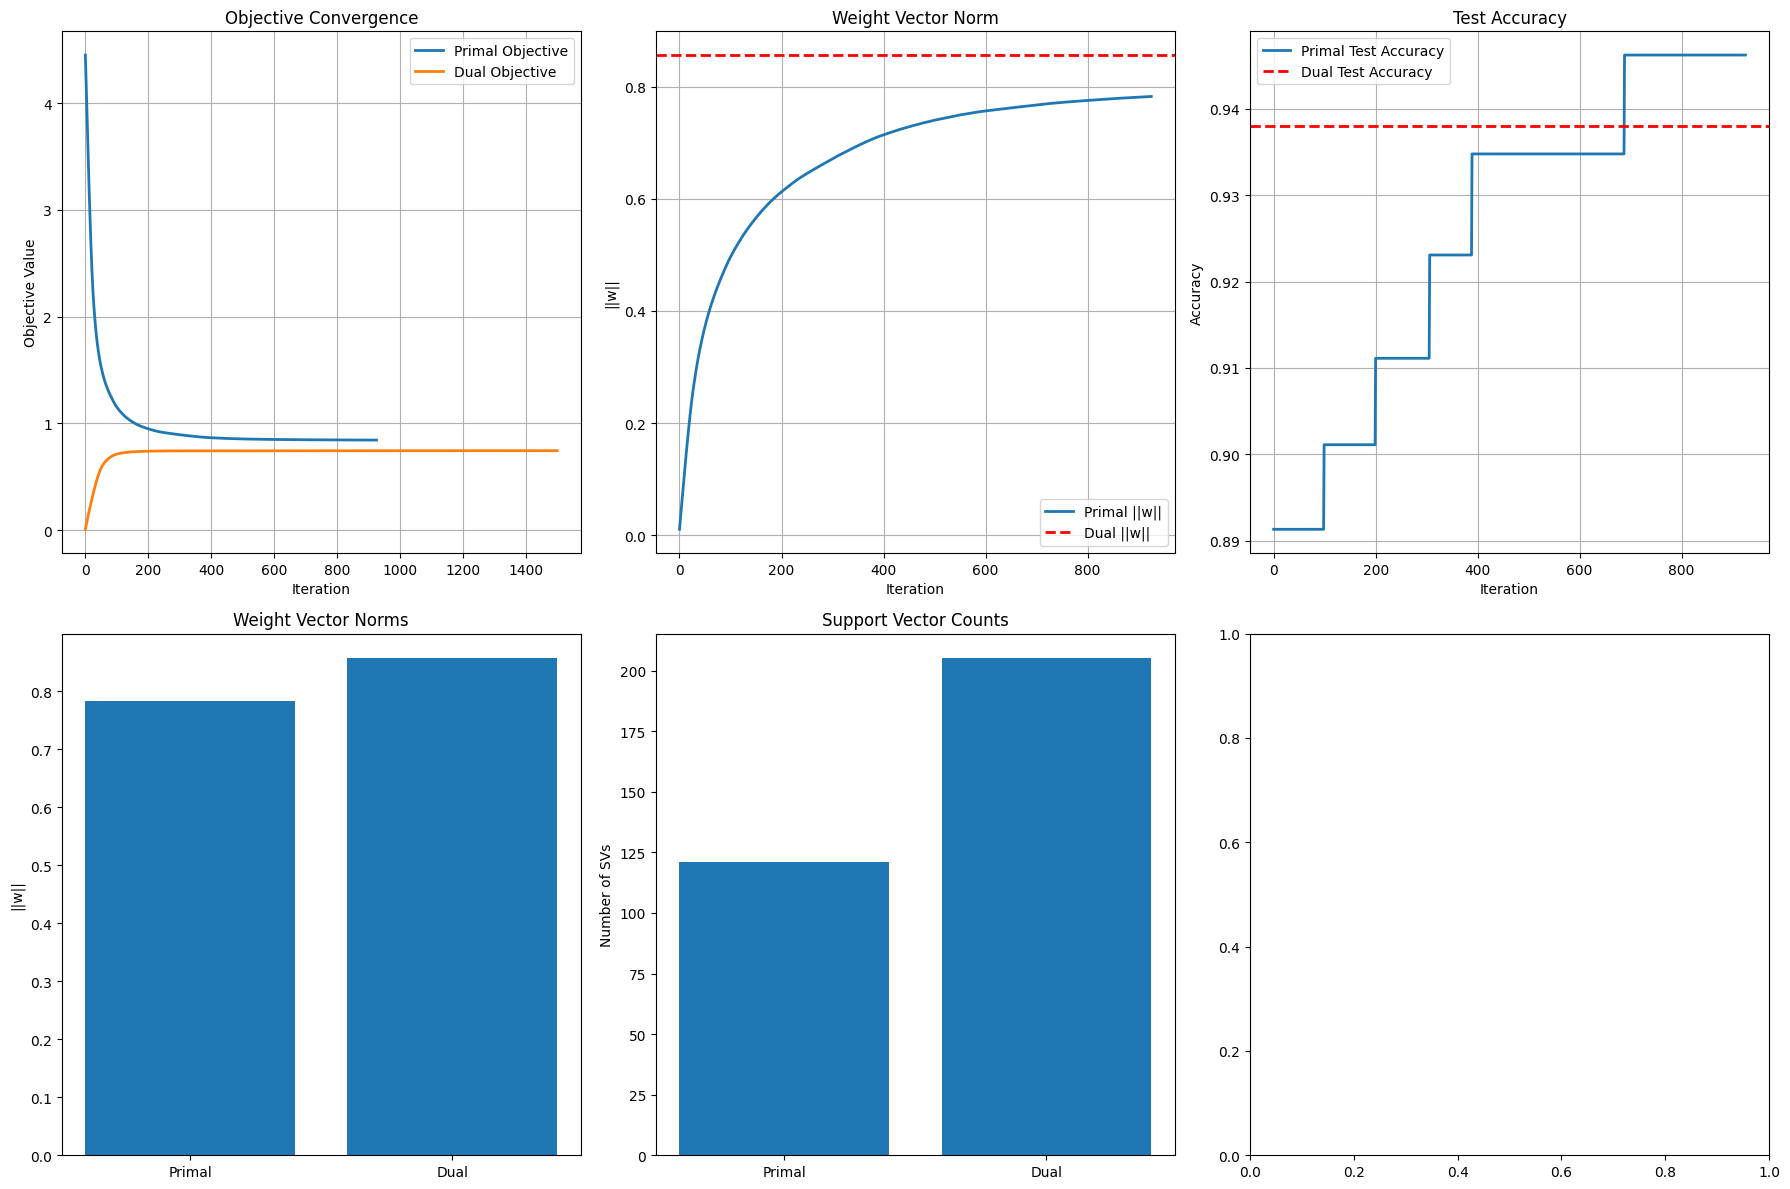


SOLUTION QUALITY ASSESSMENT
Duality Gap                 0.099475 ✓ PASS
Weight Cosine Similarity    0.916572 ✗ FAIL
Accuracy Difference         0.017699 ✓ PASS

Overall Quality: ✗ NEEDS IMPROVEMENT


In [243]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


def compare_primal_dual(primal_solution, dual_solution, X_train, y_train, X_test, y_test, C):
    """
    Comprehensive comparison between primal and dual SVM solutions
    
    Parameters:
    -----------
    primal_solution : tuple (w, hist_H, hist_w, hist_accuracy)
    dual_solution : object with alpha, support_vectors_, etc.
    X_train, y_train : training data
    X_test, y_test : test data
    C : regularization parameter
    """

    def accuracy(y, X, w):
        """Your accuracy function"""
        predictions = np.sign(X @ w)
        return accuracy_score(y, predictions)

    
    w_primal, hist_H, hist_w, hist_accuracy_primal = primal_solution
    alpha_dual = dual_solution.alpha
    
    # Reconstruct w from dual solution
    w_dual = np.sum(alpha_dual[:, np.newaxis] * y_train[:, np.newaxis] * X_train, axis=0)
    
    print("=" * 60)
    print("PRIMAL vs DUAL SVM COMPARISON")
    print("=" * 60)
    
    # 1. Compare weight vectors
    print("\n1. WEIGHT VECTOR COMPARISON:")
    print(f"Primal ||w||: {np.linalg.norm(w_primal):.6f}")
    print(f"Dual   ||w||: {np.linalg.norm(w_dual):.6f}")
    print(f"Weight vector cosine similarity: {np.dot(w_primal, w_dual) / (np.linalg.norm(w_primal) * np.linalg.norm(w_dual)):.6f}")
    
    # 2. Compare objective values
    print("\n2. OBJECTIVE VALUE COMPARISON:")
    
    # Primal objective
    margins_primal = y_train * (X_train @ w_primal)
    hinge_loss_primal = np.sum(np.maximum(0, 1 - margins_primal))
    primal_obj = 0.5 * np.linalg.norm(w_primal)**2 + C * hinge_loss_primal
    
    # Dual objective (for linear kernel)
    K = X_train @ X_train.T
    dual_obj = np.sum(alpha_dual) - 0.5 * alpha_dual.T @ ((K * np.outer(y_train, y_train)) @ alpha_dual)
    
    print(f"Primal objective: {primal_obj:.6f}")
    print(f"Dual objective:   {dual_obj:.6f}")
    print(f"Duality gap:      {primal_obj - dual_obj:.6f}")
    
    # 3. Compare predictions and accuracy
    print("\n3. PREDICTION PERFORMANCE:")
    
    # Training accuracy
    train_acc_primal = accuracy(y_train, X_train, w_primal)
    train_acc_dual = accuracy(y_train, X_train, w_dual)
    
    # Test accuracy  
    test_acc_primal = accuracy(y_test, X_test, w_primal)
    test_acc_dual = accuracy(y_test, X_test, w_dual)
    
    print(f"Training accuracy - Primal: {train_acc_primal:.4f}, Dual: {train_acc_dual:.4f}")
    print(f"Test accuracy     - Primal: {test_acc_primal:.4f}, Dual: {test_acc_dual:.4f}")
    
    # 4. Compare support vectors
    print("\n4. SUPPORT VECTORS:")
    
    # For primal, we can approximate support vectors as points with small margin
    margins_primal_sv = y_train * (X_train @ w_primal)
    primal_sv_indices = np.where(margins_primal_sv <= 1 + 1e-3)[0]
    
    dual_sv_indices = np.where(alpha_dual > 1e-5)[0]
    
    print(f"Primal SV count: {len(primal_sv_indices)}")
    print(f"Dual SV count:   {len(dual_sv_indices)}")
    
    # Check overlap in support vectors
    sv_overlap = len(np.intersect1d(primal_sv_indices, dual_sv_indices))
    print(f"Support vector overlap: {sv_overlap} points")
    
    # 5. Check KKT conditions for dual solution
    print("\n5. KKT CONDITIONS CHECK (Dual):")
    
    # Stationarity
    w_reconstructed = np.sum(alpha_dual[:, np.newaxis] * y_train[:, np.newaxis] * X_train, axis=0)
    stationarity_violation = np.linalg.norm(w_dual - w_reconstructed)
    print(f"Stationarity violation: {stationarity_violation:.2e}")
    
    # Complementary slackness
    margins_dual = y_train * (X_train @ w_dual)
    comp_slackness_violation = 0
    for i in range(len(alpha_dual)):
        if alpha_dual[i] > 1e-5 and alpha_dual[i] < C - 1e-5:
            # Should have y_i(w·x_i) = 1
            comp_slackness_violation += abs(margins_dual[i] - 1)
        elif alpha_dual[i] >= C - 1e-5:
            # Should have y_i(w·x_i) <= 1
            if margins_dual[i] > 1 + 1e-3:
                comp_slackness_violation += margins_dual[i] - 1
    print(f"Complementary slackness violation: {comp_slackness_violation:.2e}")
    
    # 6. Constraint satisfaction
    print("\n6. CONSTRAINT SATISFACTION:")
    dual_constraint_violation = abs(np.dot(alpha_dual, y_train))
    print(f"Dual constraint ∑αᵢyᵢ = 0 violation: {dual_constraint_violation:.2e}")
    
    box_constraint_violation = np.sum((alpha_dual < -1e-5) | (alpha_dual > C + 1e-5))
    print(f"Box constraint violations: {box_constraint_violation}")
    
    return {
        'w_primal': w_primal,
        'w_dual': w_dual,
        'primal_objective': primal_obj,
        'dual_objective': dual_obj,
        'duality_gap': primal_obj - dual_obj,
        'train_acc_primal': train_acc_primal,
        'train_acc_dual': train_acc_dual,
        'test_acc_primal': test_acc_primal,
        'test_acc_dual': test_acc_dual,
        'primal_sv_indices': primal_sv_indices,
        'dual_sv_indices': dual_sv_indices
    }

def plot_comparison(comparison_results, primal_history, dual_history, X_train, y_train):
    """Plot comprehensive comparison between primal and dual solutions"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Convergence comparison
    axes[0, 0].plot(primal_history[1], label='Primal Objective', linewidth=2)
    axes[0, 0].plot(dual_history[0], label='Dual Objective', linewidth=2)
    axes[0, 0].set_title('Objective Convergence')
    axes[0, 0].set_xlabel('Iteration')
    axes[0, 0].set_ylabel('Objective Value')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # 2. Weight norm comparison
    axes[0, 1].plot(primal_history[2], label='Primal ||w||', linewidth=2)
    axes[0, 1].axhline(y=np.linalg.norm(comparison_results['w_dual']), 
                      color='red', linestyle='--', label='Dual ||w||', linewidth=2)
    axes[0, 1].set_title('Weight Vector Norm')
    axes[0, 1].set_xlabel('Iteration')
    axes[0, 1].set_ylabel('||w||')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # 3. Accuracy comparison
    axes[0, 2].plot(primal_history[3], label='Primal Test Accuracy', linewidth=2)
    axes[0, 2].axhline(y=comparison_results['test_acc_dual'], 
                      color='red', linestyle='--', label='Dual Test Accuracy', linewidth=2)
    axes[0, 2].set_title('Test Accuracy')
    axes[0, 2].set_xlabel('Iteration')
    axes[0, 2].set_ylabel('Accuracy')
    axes[0, 2].legend()
    axes[0, 2].grid(True)
    
    # 4. Weight vector comparison
    w_primal_norm = comparison_results['w_primal'] / np.linalg.norm(comparison_results['w_primal'])
    w_dual_norm = comparison_results['w_dual'] / np.linalg.norm(comparison_results['w_dual'])
    
    axes[1, 0].bar([0, 1], [np.linalg.norm(comparison_results['w_primal']), 
                           np.linalg.norm(comparison_results['w_dual'])])
    axes[1, 0].set_title('Weight Vector Norms')
    axes[1, 0].set_xticks([0, 1])
    axes[1, 0].set_xticklabels(['Primal', 'Dual'])
    axes[1, 0].set_ylabel('||w||')
    
    # 5. Support vector comparison
    sv_counts = [len(comparison_results['primal_sv_indices']), 
                len(comparison_results['dual_sv_indices'])]
    axes[1, 1].bar([0, 1], sv_counts)
    axes[1, 1].set_title('Support Vector Counts')
    axes[1, 1].set_xticks([0, 1])
    axes[1, 1].set_xticklabels(['Primal', 'Dual'])
    axes[1, 1].set_ylabel('Number of SVs')
    
    # 6. Decision boundaries (for 2D data)
    if X_train.shape[1] == 2:
        h = 0.02
        x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
        y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                            np.arange(y_min, y_max, h))
        
        # Primal decision boundary
        Z_primal = np.sign(np.c_[xx.ravel(), yy.ravel()] @ comparison_results['w_primal'])
        Z_primal = Z_primal.reshape(xx.shape)
        
        # Dual decision boundary  
        Z_dual = np.sign(np.c_[xx.ravel(), yy.ravel()] @ comparison_results['w_dual'])
        Z_dual = Z_dual.reshape(xx.shape)
        
        # Plot difference
        Z_diff = (Z_primal != Z_dual).astype(float)
        
        axes[1, 2].contourf(xx, yy, Z_diff, alpha=0.3, cmap='Reds')
        axes[1, 2].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', alpha=0.6)
        axes[1, 2].set_title('Decision Boundary Differences\n(Red = disagreement)')
        axes[1, 2].set_xlabel('Feature 1')
        axes[1, 2].set_ylabel('Feature 2')
    
    plt.tight_layout()
    plt.show()

# Example usage with your existing code
def run_complete_comparison(X_train, y_train, X_test, y_test, C=0.1):
    """Run complete primal-dual comparison"""
    
    # Your primal solution
    print("Running Primal SVM...")
    w_initial = np.zeros(X_train.shape[1])
    primal_solution = primal(y_train, X_train, w_initial, C=C, step=0.001, iters=1500, tol=1e-6)
    
    # Your dual solution (using Nesterov)
    print("Running Dual SVM (Nesterov)...")
    dual_svm = LinearNesterovDualSVM(C=C, max_iter=1500, learning_rate=0.00002, momentum=0.9)
    dual_history = dual_svm.fit(X_train, y_train)
    
    # Compare solutions
    comparison = compare_primal_dual(
        primal_solution, dual_svm, X_train, y_train, X_test, y_test, C
    )
    
    # Plot comprehensive comparison
    plot_comparison(comparison, primal_solution, dual_history, X_train, y_train)
    
    return comparison, primal_solution, dual_svm

# Quality assessment metrics
def assess_solution_quality(comparison_results):
    """Provide quantitative assessment of solution quality"""
    
    print("\n" + "="*60)
    print("SOLUTION QUALITY ASSESSMENT")
    print("="*60)
    
    metrics = []
    
    # 1. Duality gap (should be small)
    duality_gap = comparison_results['duality_gap']
    metrics.append(('Duality Gap', duality_gap, duality_gap < 0.1))
    
    # 2. Weight vector similarity
    w_similarity = np.dot(comparison_results['w_primal'], comparison_results['w_dual']) / \
                  (np.linalg.norm(comparison_results['w_primal']) * 
                   np.linalg.norm(comparison_results['w_dual']))
    metrics.append(('Weight Cosine Similarity', w_similarity, w_similarity > 0.95))
    
    # 3. Accuracy consistency
    acc_diff = abs(comparison_results['test_acc_primal'] - comparison_results['test_acc_dual'])
    metrics.append(('Accuracy Difference', acc_diff, acc_diff < 0.05))
    
    # 4. Print assessment
    for name, value, passed in metrics:
        status = "✓ PASS" if passed else "✗ FAIL"
        print(f"{name:25} {value:10.6f} {status}")
    
    # Overall assessment
    all_passed = all(passed for _, _, passed in metrics)
    print(f"\nOverall Quality: {'✓ GOOD' if all_passed else '✗ NEEDS IMPROVEMENT'}")

# Assuming X_train, y_train, X_test, y_test are defined
comparison, primal_sol, dual_svm = run_complete_comparison(X_train_with_b, y_train, X_test_with_b, y_test, C=0.01)
assess_solution_quality(comparison)

## SVM Двойственная задача

$L(a) = \min \dfrac{1}{2} \sum_i \sum_j y_i y_j a_i a_j <x_i, x_j> - \sum a_i$

s.t.:

$\sum y_i a_i = 0$

$0 \le a_i \le C$

$L'(a) = a_i y_i y_j <x_i, x_j> - 1$

Для учета ограничения $\sum y_i a_i = 0$ рассмотрим 2 способа:
1. метод пенальти, за выход из $\sum y_i a_i = 0$ накладываем штраф. Тогда

$L(a) = \min \dfrac{1}{2} \sum_i \sum_j y_i y_j a_i a_j <x_i, x_j> - \sum a_i + 10 * ||y a||^2$

$\nabla L(a) = a_i y_i y_j <x_i, x_j> - 1 + 10 * 2 * y * ||y a||$

2. метод проекции на $\sum y_i a_i = 0$

In [285]:
K = X_train @ X_train.T
print(f'conditiona number of X dot X.T : {np.linalg.cond(K)}')
print(f'conditiona number of (X dot X.T - 0.01*I) : {np.linalg.cond(K - 0.01 * np.eye(K.shape[0]))}')

conditiona number of X dot X.T : 3.5055649245917454e+19
conditiona number of (X dot X.T - 0.01*I) : 423446.898540223


Так как число определенности $<X, X>$ слишком большое применим регуляризацию $(<X, X> - \lambda I)$ с параметром $\lambda=0.01$. В тестах не показал, но по итогу это практически не влияет на ход методов. Влияние оказывают значения $\lambda$ на уровне сотен тысяч, но это уже кажется не правильным и отдельно не тестировал.

Iter 0, Obj: -0.025244, Grad norm: 21.354157


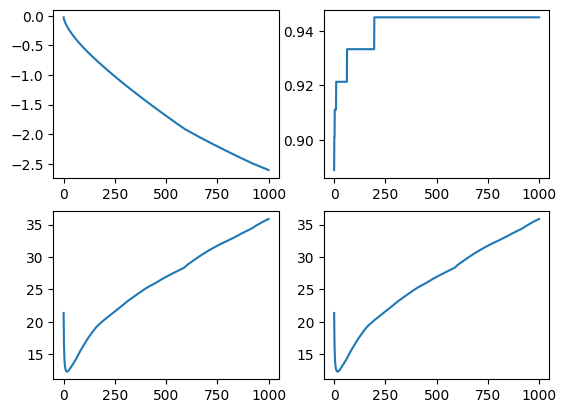

(0.945054945054945, 0.9557522123893806)


In [23]:

def dual_svm_gd_projection(X, y, C, max_iters=10000, tol=1e-6, learning_rate=0.001, lmbd = 0.0):
    n_samples = X.shape[0]
    alpha = np.zeros(n_samples)
    hist_L = []
    hist_g = []
    hist_accuracy = []
    # Precompute kernel matrix (linear kernel)
    K = X @ X.T
    K = K - lmbd * np.eye(K.shape[0])

    for iter in range(max_iters):
        # Compute gradient
        grad = (K @ (alpha * y)) * y - 1
        hist_g.append(np.linalg.norm(grad))
        # Gradient step
        alpha_new = alpha - learning_rate * grad

        # Project onto constraints: 0 <= alpha <= C and sum(alpha * y) = 0
        alpha_new = np.clip(alpha_new, 0, C)

        # Enforce linear constraint: project onto hyperplane sum(alpha * y) = 0
        # This is the correct projection step
        current_sum = np.dot(alpha_new, y)
        alpha_new = alpha_new - (current_sum / np.dot(y, y)) * y

        # Re-clip after projection (projection might violate box constraints)
        alpha_new = np.clip(alpha_new, 0, C)

        alpha = alpha_new
        # Compute objective
        obj = 0.5 * alpha @ (K * np.outer(y, y)) @ alpha - alpha.sum()
        hist_L.append(obj)
        hist_accuracy.append(dual_accuracy(alpha)[0])
        if iter % 10000 == 0:
            print(f"Iter {iter}, Obj: {obj:.6f}, Grad norm: {np.linalg.norm(grad):.6f}")
        if np.linalg.norm(grad) < tol:
            break
    return alpha, hist_L, hist_accuracy, hist_g

ITERS = 1000
STEP = 0.00007
TOL = 1e-6
LMBD = 0.01

# a = np.random.rand(*y_train.shape)
a_star, hist_obj, hist_accuracy, hist_g = dual_svm_gd_projection(X_train, y_train, C, ITERS, TOL, STEP, LMBD)


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)
ax1.plot(hist_obj)
ax2.plot(hist_accuracy)

ax3.plot(hist_g)
ax4.plot(hist_g)

plt.show()

w_dual = np.sum(a_star[:, np.newaxis] * y_train[:, np.newaxis] * X_train, axis=0)
print(accuracy(y_test, X_test, w_dual))

## Адаптивные методы

In [24]:
from abc import ABC, abstractmethod
from typing import Callable

class StepSize(ABC):

    @abstractmethod
    def __call__(
        self,
        x: np.ndarray,
        h: np.float64,
        k: int,
        gradf: Callable[[np.float64], np.float64],
        f: Callable[[np.float64], np.float64],
    ) -> np.ndarray:
        raise NotImplementedError()

class Armijo(StepSize):

    def __init__(
        self,
        beta: np.float64 = 0.3,
        rho: np.float64 = 0.1,
        alpha0: np.float64 = 1,
    ):
        self.beta = beta
        self.rho = rho
        self.alpha0 = alpha0

    def __call__(
        self,
        x: np.ndarray,
        h: np.float64,
        k: int,
        gradf: Callable[[np.float64], np.float64],
        f: Callable[[np.float64], np.float64],
    ):
        beta, rho, alpha = self.beta, self.rho, self.alpha0
        fx = f(x)
        hg = h.dot(gradf(x))
        while f(x + alpha * h) > fx + beta * alpha * hg:
            alpha *= rho
        return alpha


class Wolfe(StepSize):

    def __init__(
        self,
        beta1: np.float64 = 0.3,
        beta2: np.float64 = 0.9,
        rho1: np.float64 = 0.1,
        rho2: np.float64 = 2,
        alpha0: np.float64 = 1,
    ):
        self.beta1, self.beta2 = beta1, beta2
        self.rho1, self.rho2 = rho1, rho2
        self.alpha0 = alpha0

    def __call__(
        self,
        x: np.ndarray,
        h: np.float64,
        k: int,
        gradf: Callable[[np.float64], np.float64],
        f: Callable[[np.float64], np.float64],
    ):
        beta1, rho1, alpha = self.beta1, self.rho1, self.alpha0
        beta2, rho2 = self.beta2, self.rho2
        lb, ub = 0, np.inf
        fx = f(x)
        g = gradf(x)
        hg = h.dot(g)
        while True:
            x_new = x + alpha * h
            if f(x_new) > fx + beta1 * alpha * hg:
                ub = alpha
                alpha = (lb + ub) / 2
            elif gradf(x_new).dot(h) < beta2 * hg:
                lb = alpha
                if np.isinf(ub):
                    alpha = 2 * lb
                else:
                    alpha = 0.5 * (lb + ub)
            else:
                return alpha
            if ub - lb <= 1e-12:
                return alpha

def adaptive_gradient_descent(
    obj: Callable[[np.ndarray], np.float64],
    grad: Callable[[np.ndarray], np.ndarray],
    a0: np.ndarray,
    L0: np.float64,
    tol: np.float64 = 1e-3,
    max_iter: int = 1000,
) -> list[np.ndarray]:
    """
    Adaptive Gradient Descent

    Args:
        obj: objective function
        grad: gradient of the objective function
        x0: initial point
        L0: initial value of L
        tol: tolerance
        max_iter: maximum number of iterations

    Returns:
        history of optimal x.
    """
    a = a0.astype(np.float64).copy()
    grad_history: list[np.float64] = []
    obj_history: list[np.float64] = []
    L = L0.copy()

    for _ in range(max_iter):
        L /= 2
        grad_a = grad(a)
        grad_history.append(np.linalg.norm(grad_a))
        if np.linalg.norm(grad_a) < tol:
            break

        while True:
            a_next = a - 1 / L * grad_a
            obj_next = obj(a_next)
            obj_history.append(obj_next)
            if (
                obj_next
                <= obj(a)
                + np.dot(grad_a, a_next - a)
                + L / 2 * np.linalg.norm(a_next - a) ** 2
            ):
                a = a_next.copy()
                break

            L *= 2

    return a, obj_history, grad_history

Iter 0, Obj: 2524.815715, Grad norm: 21.354157
DONE 9.00399754755199e-11


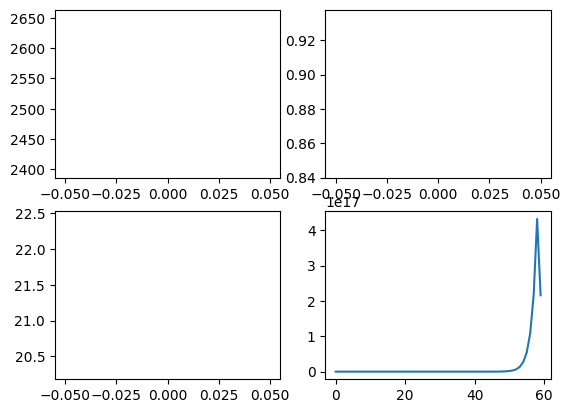

(0.8888888888888888, 0.911504424778761)


In [25]:
def adaptive_gd_projection(X, y, C, L0, max_iters=10000, tol=1e-6, lmbd=0.0):
    n_samples = X.shape[0]
    a = np.zeros(n_samples)
    hist_obj = []
    hist_g = []
    hist_accuracy = []
    hist_L = []
    # Precompute kernel matrix (linear kernel)
    K = X @ X.T
    K = K - lmbd * np.eye(K.shape[0])
    L = L0

    def obj(alpha):
        return 0.5 * alpha @ (K * np.outer(y, y)) @ alpha - alpha.sum()
    def grad(alpha):
        return (K @ (alpha * y)) * y - 1
    def corrected_alpha(alpha_new):
        # Project onto constraints: 0 <= alpha <= C and sum(alpha * y) = 0
        alpha_new = np.clip(alpha_new, 0, C)

        # Enforce linear constraint: project onto hyperplane sum(alpha * y) = 0
        # This is the correct projection step
        current_sum = np.dot(alpha_new, y)
        alpha_new = alpha_new - (current_sum / np.dot(y, y)) * y

        # Re-clip after projection (projection might violate box constraints)
        alpha_new = np.clip(alpha_new, 0, C)

        return alpha_new
    obj_next = obj(a)
    for iter in range(max_iters):
        L /= 2
        # Compute gradient
        grad_next = grad(a)
        # Gradient step
        while True:
            hist_L.append(L)
            alpha_new = a - 1/L * grad_next
            a = corrected_alpha(alpha_new)
            if (
                obj(alpha_new)
                <= obj(a)
                + np.dot(grad_next, alpha_new - a)
                + L / 2 * np.linalg.norm(alpha_new - a) ** 2
            ):
                a = alpha_new.copy()
                break
            L *= 2
        obj_cur = obj(a)
        if (np.abs(obj_cur - obj_next) < tol):
            print(f'DONE {np.abs(obj_cur - obj_next)}')
            break
        obj_next = obj_cur
        hist_g.append(np.linalg.norm(grad_next))
        hist_accuracy.append(dual_accuracy(a)[0])
        hist_obj.append(obj_next)

        if iter % 1000 == 0:
            print(f"Iter {iter}, Obj: {obj_next:.6f}, Grad norm: {np.linalg.norm(grad_next):.6f}")
    return a, hist_obj, hist_accuracy, hist_g, hist_L

ITERS = 3000
L0 = 3
C = 0.1
TOL = 1e-10
LMBD = 0.01
a_star, hist_obj, hist_accuracy, hist_g, hist_L = adaptive_gd_projection(X_train, y_train, C, L0, ITERS, TOL, LMBD)


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)
ax1.plot(hist_obj)
ax2.plot(hist_accuracy)

ax3.plot(hist_g)
ax4.plot(hist_L)

plt.show()

w_dual = np.sum(a_star[:, np.newaxis] * y_train[:, np.newaxis] * X_train, axis=0)
print(accuracy(y_test, X_test, w_dual))

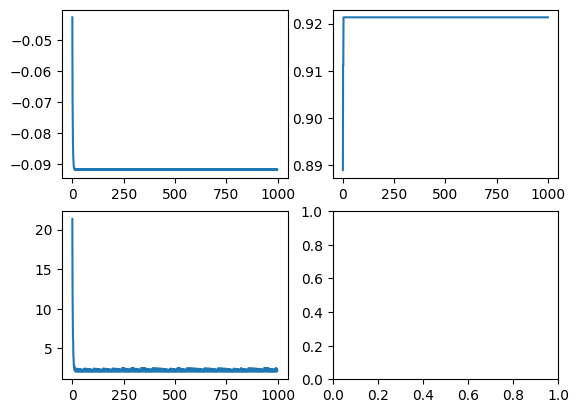

(0.9213483146067416, 0.9380530973451328)


In [26]:

def adaptive_gd_with_penalty(X, y, L0, C, iters, tol, lmbd):
    K = X @ X.T
    K = K - lmbd * np.eye(K.shape[0])
    def obj(a):
        # return 0.5 * (np.outer(a*y, a*y) * K).sum() - np.sum(a)
        return 0.5 * a @ (K * np.outer(y, y)) @ a - a.sum()


    def grad(a):
        return y * (K @ (a * y)) - 1

    def penalty(a):
        p = np.dot(y, a)
        return 10 * (p ** 2)

    def penalty_grad(a):
        p = np.dot(y, a)
        return 20 * p * y

    a = np.zeros(y.shape)
    L = L0
    hist_obj = []
    hist_g = []
    hist_accuracy = []
    obj_next = obj(a) + penalty(a)
    for k in range(iters):
        L /= 2
        a = np.clip(a, 0, C)
        grad_next = grad(a) + penalty_grad(a)
        while True:
            a_next = a - 1 / L * grad_next
            if (
                obj(a_next) + penalty(a_next)
                <= obj(a) + penalty(a)
                + np.dot(grad_next, a_next - a)
                + L / 2 * np.linalg.norm(a_next - a) ** 2
            ):
                a = a_next.copy()
                break

            L *= 2

        obj_cur = obj(a) + penalty(a)
        if (np.abs(obj_cur - obj_next) < tol):
            print(f'DONE {np.abs(obj_cur - obj_next)}')
            break
        obj_next = obj_cur
        hist_g.append(np.linalg.norm(grad_next))
        hist_accuracy.append(dual_accuracy(a)[0])
        hist_obj.append(obj_next)

    return a, hist_obj, hist_g, hist_accuracy

ITERS = 1000
L0 = 3
C = 0.9
LMBD = -1000
a_star, hist_obj, hist_g, hist_accuracy = adaptive_gd_with_penalty(X_train, y_train, C, L0, ITERS, 1e-10, LMBD)


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)
ax1.plot(hist_obj)
ax2.plot(hist_accuracy)
ax3.plot(hist_g)

plt.show()

w_dual = np.sum(a_star[:, np.newaxis] * y_train[:, np.newaxis] * X_train, axis=0)
print(accuracy(y_test, X_test, w_dual))

-3.5795805984448137


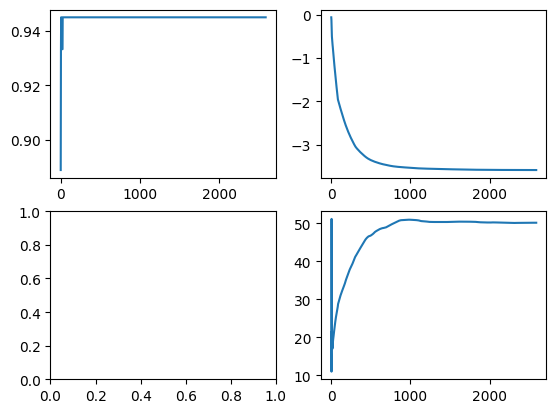

In [27]:


def cool_step_gd_with_penalty(y, X, C, step_type: str, iters, tol, lmbd):
    a = np.zeros(y.shape)
    K = X @ X.T
    K = K - lmbd * np.eye(K.shape[0])
    def obj(a):
        return 0.5 * (np.outer(a*y, a*y) * K).sum() - np.sum(a)

    def grad(a):
        return y * (K @ (a * y)) - 1

    def penalty(a):
        p = np.dot(y, a)
        return 10 * (p ** 2)

    def penalty_grad(a):
        p = np.dot(y, a)
        return 20 * p * y
    
    def obj_full(a):
        return obj(a) + penalty(a)
    
    def grad_full(a):
        return grad(a) + penalty_grad(a)
    
    step: StepSize
    if step_type == "armijo":
        step = Armijo()
    elif step_type == "wolfe":
        step = Wolfe()

    hist_obj = []
    hist_accuracy = []
    hist_g = []
    for k in range(iters):
        g = grad_full(a)
        h = -g
        a = a + step(a, h, k, grad_full, obj_full) * h
        a = np.clip(a, 0, C)
        hist_accuracy.append(dual_accuracy(a)[0])
        H = obj_full(a)
        if (len(hist_obj) > 0 and np.abs(H - hist_obj[-1]) < tol):
            break

        hist_g.append(np.linalg.norm(g))
        hist_obj.append(H)
    return a, hist_obj, hist_accuracy, hist_g

C = 0.1
ITERS = 2590
TOL = 1e-10
LMBD = 0.01
# a = np.random.rand(*y_train.shape)
a_star, hist_obj, hist_accuracy, hist_g = cool_step_gd_with_penalty(y_train, X_train, C, 'wolfe', ITERS, TOL, LMBD)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)
ax1.plot(hist_accuracy)
ax2.plot(hist_obj)

ax4.plot(hist_g)
print(hist_obj[-1])

plt.show()

-3.537861591507878


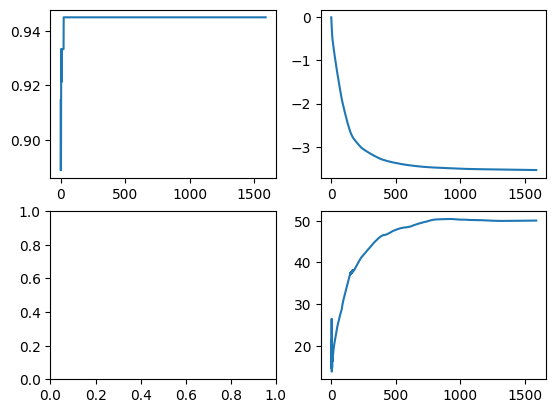

In [28]:
def cool_step_gd_with_projection(y, X, C, step_type: str, iters, tol, lmbd):
    a = np.zeros(y.shape)
    K = X @ X.T
    K = K - lmbd * np.eye(K.shape[0])
    def obj(a):
        return 0.5 * (np.outer(a*y, a*y) * K).sum() - np.sum(a)

    def grad(a):
        return y * (K @ (a * y)) - 1
    
    def corrected_alpha(alpha_new):
        # Project onto constraints: 0 <= alpha <= C and sum(alpha * y) = 0
        alpha_new = np.clip(alpha_new, 0, C)

        # Enforce linear constraint: project onto hyperplane sum(alpha * y) = 0
        # This is the correct projection step
        current_sum = np.dot(alpha_new, y)
        alpha_new = alpha_new - (current_sum / np.dot(y, y)) * y

        # Re-clip after projection (projection might violate box constraints)
        alpha_new = np.clip(alpha_new, 0, C)
        return alpha_new

    step: StepSize
    if step_type == "armijo":
        step = Armijo(rho = 0.05, beta=0.8, alpha0=0.0001)
    elif step_type == "wolfe":
        step = Wolfe()

    hist_obj = []
    hist_accuracy = []
    hist_g = []
    for k in range(iters):
        H = obj(a)
        if (len(hist_obj) > 0 and np.abs(H - hist_obj[-1]) < tol):
            break
        g = grad(a)

        hist_g.append(np.linalg.norm(g))
        hist_obj.append(H)
        h = -g
        a = a + step(a, h, k, grad, obj) * h
        a = corrected_alpha(a)
        hist_accuracy.append(dual_accuracy(a)[0])
    return a, hist_obj, hist_accuracy, hist_g

C = 0.1
ITERS = 1590
TOL = 1e-10
LMBD = 0.01

a_star, hist_obj, hist_accuracy, hist_g = cool_step_gd_with_projection(y_train, X_train, C, 'wolfe', ITERS, TOL, LMBD)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)
ax1.plot(hist_accuracy)
ax2.plot(hist_obj)

ax4.plot(hist_g)
print(hist_obj[-1])

plt.show()

In [31]:
import cvxpy as cvx

def cvx_solve():
    # 0.5 * a @ (K * np.outer(y, y)) @ a - a.sum()
    cvx_a = cvx.Variable(y_train.shape[0])
    cvx_obj = cvx.Minimize(0.5 * cvx.quad_form(cvx_a, cvx.psd_wrap(((X_train @ X_train.T) * np.outer(y_train, y_train)))) - cvx.sum(cvx_a))
    cvx_constraint = [cvx_a @ y_train == 0, cvx_a >= 0, cvx_a <= C]
    cvx_problem = cvx.Problem(cvx_obj, cvx_constraint)
    cvx_problem.solve(verbose=True)

    return cvx_a.value

In [270]:
#==============
# до сюда
#==============

Iter 0, Obj: -0.003893, Grad norm: 21.354157
Iter 0, Obj: 849579.406868, Grad norm: 21.354157
DONE 0.0


(CVXPY) Nov 07 06:30:51 PM: Your problem has 456 variables, 913 constraints, and 0 parameters.
(CVXPY) Nov 07 06:30:51 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Nov 07 06:30:51 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Nov 07 06:30:51 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Nov 07 06:30:51 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Nov 07 06:30:51 PM: Compiling problem (target solver=OSQP).
(CVXPY) Nov 07 06:30:51 PM: Reduction chain: CvxAttr2Constr -> Qp2SymbolicQp -> QpMatrixStuffing -> OSQP
(CVXPY) Nov 07 06:30:51 PM: Applying reduction CvxAttr2Constr
(CVXPY) Nov 07 06:30:51 PM: Applying reduction Qp2SymbolicQp
(CVXPY) Nov 07 06:30:51 PM: Applying reduction QpMatrixStuffing
(CVXPY) Nov 07 06:30:51 PM: Applying reduction OSQP
(CVXPY) Nov 07 06:30:51 PM: Finished problem compilation 

                                     CVXPY                                     
                                     v1.7.3                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 456, constraints m = 913
          nnz(P) + nnz(A) = 105564
settings: algebra = Built-in,
          OSQPIn

(CVXPY) Nov 07 06:30:51 PM: Problem status: optimal
(CVXPY) Nov 07 06:30:51 PM: Optimal value: -3.575e+00
(CVXPY) Nov 07 06:30:51 PM: Compilation took 1.086e-01 seconds
(CVXPY) Nov 07 06:30:51 PM: Solver (including time spent in interface) took 2.260e-01 seconds


 400  -3.6588e+00   9.95e-04   3.37e-03  -8.34e-02   3.37e-03   1.00e-01    1.16e-01s
 600  -3.5751e+00   1.23e-04   2.30e-04  -3.82e-04   2.30e-04   1.00e-01    1.57e-01s
 800  -3.5752e+00   8.61e-06   4.05e-05  -4.54e-04   4.05e-05   1.00e-01    1.98e-01s
 825  -3.5748e+00   5.66e-06   4.16e-05  -5.31e-05   4.16e-05   1.00e-01    2.03e-01s
plsh  -3.5747e+00   6.77e-17   1.42e-14  -1.07e-15   1.42e-14   --------    2.15e-01s

status:               solved
solution polishing:   successful
number of iterations: 825
optimal objective:    -3.5747
dual objective:       -3.5747
duality gap:          -1.0673e-15
primal-dual integral: 6.9475e+01
run time:             2.15e-01s
optimal rho estimate: 1.52e-01

-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
CVXPY result alpha: [ 1.65344016e-20  2.45096526e-

/var/folders/_q/wfkf0_v13rz2f2w6vtlg9g2h0000gp/T/ipykernel_46187/3983904591.py:105: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


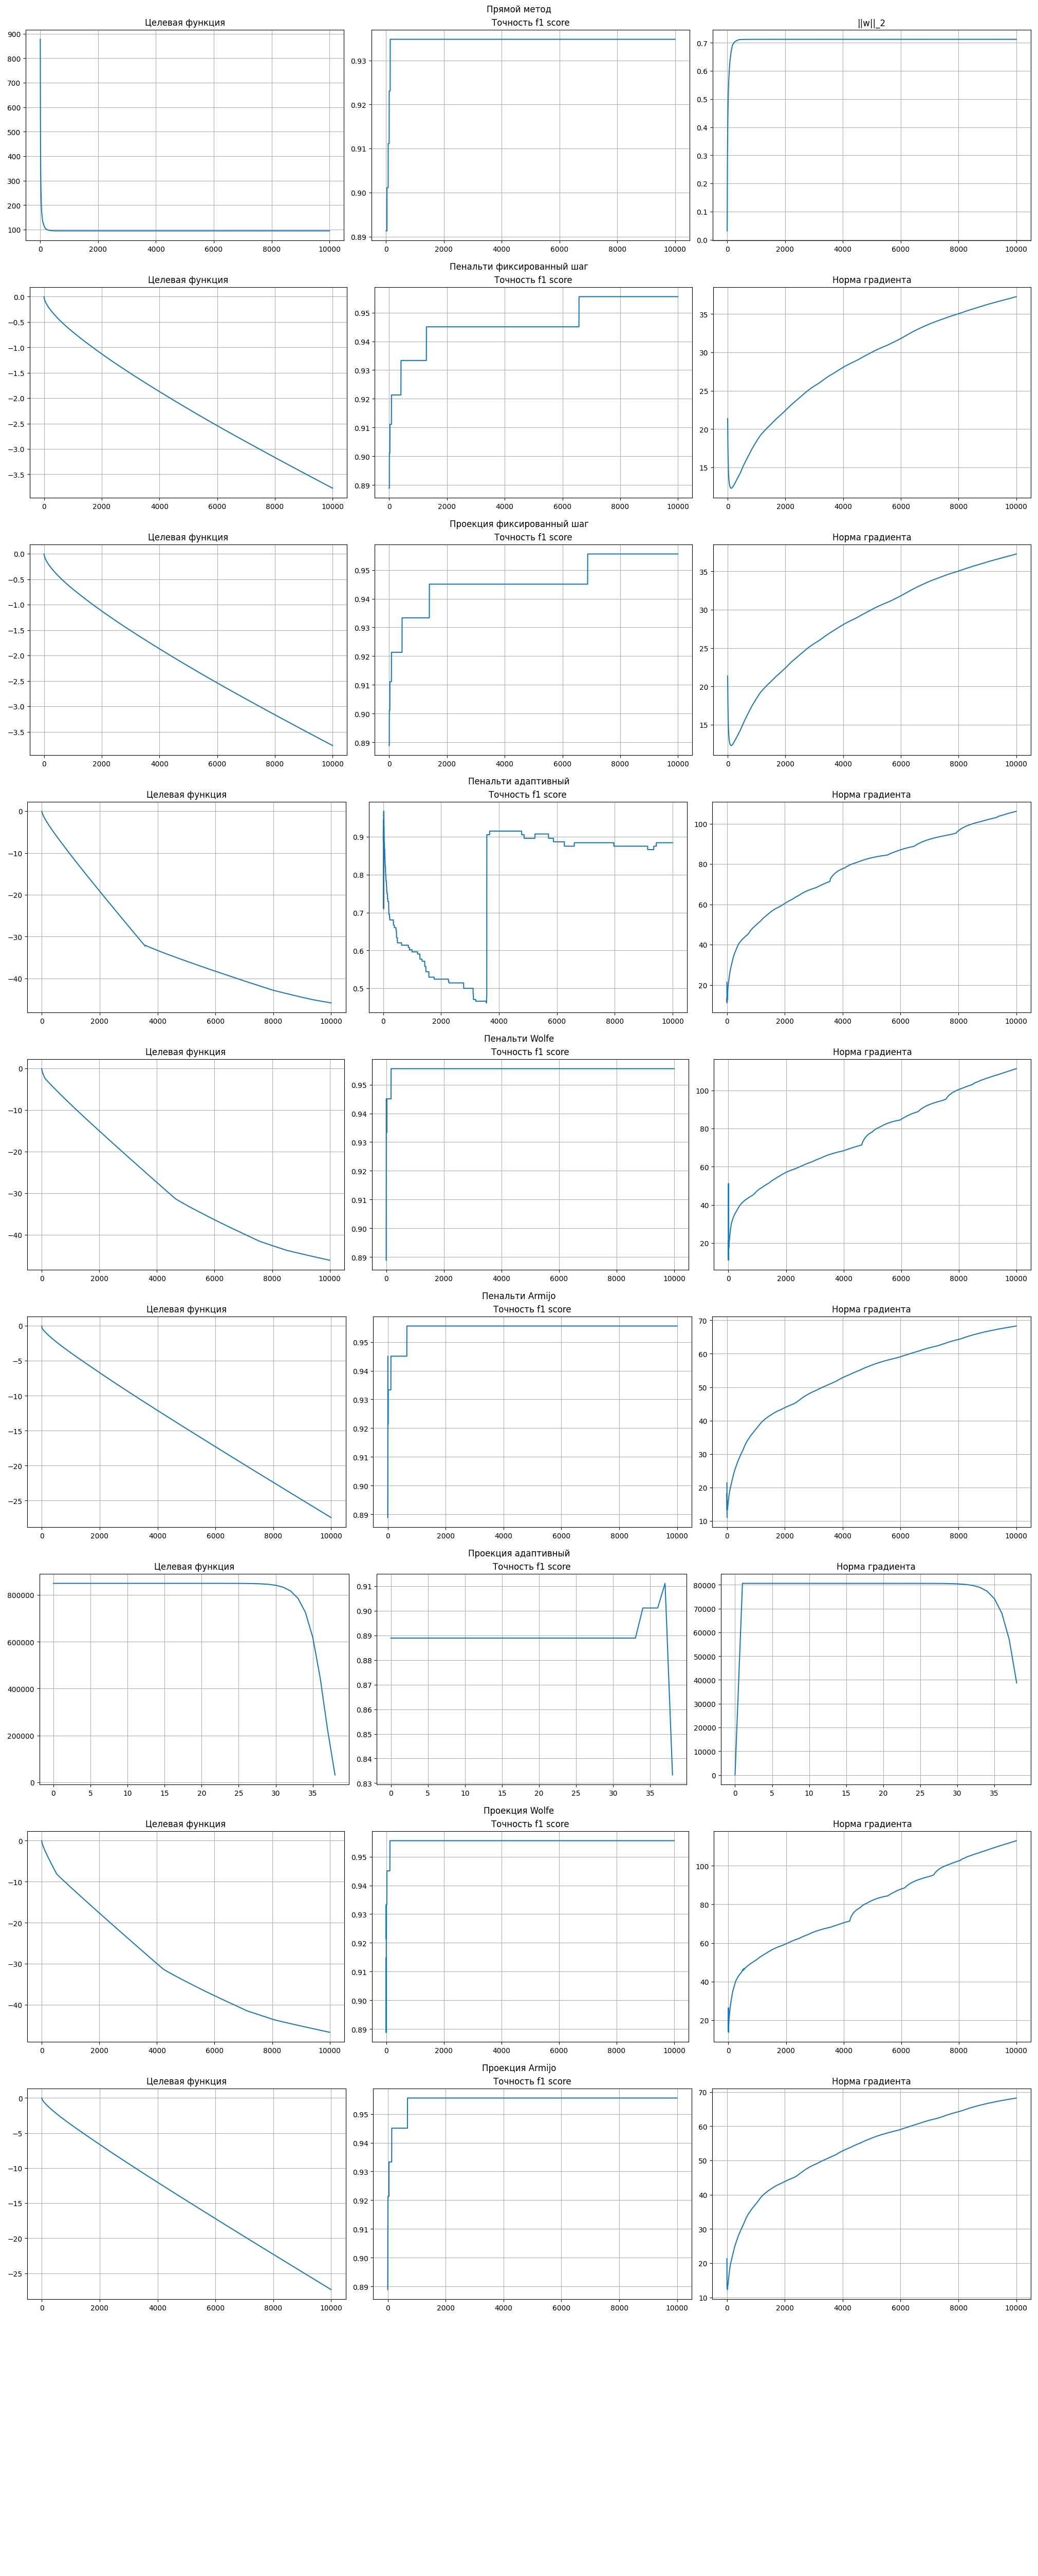

In [ ]:
def makegraph(axs0, hist_obj, hist_accuracy, hist_grad):
    axs0[0].plot(hist_obj)
    axs0[0].set_title('Целевая функция')
    axs0[1].plot(hist_accuracy)
    axs0[1].set_title('Точность f1 score')
    axs0[2].plot(hist_grad)
    axs0[2].set_title('Норма градиента')
    axs0[0].grid()
    axs0[1].grid()
    axs0[2].grid()

def experiments():
    fig = plt.figure(layout='constrained', figsize=(20, 50))


    subfigs = fig.subfigures(nrows=10, ncols=1)
    C = 3
    STEP = 0.00001
    ITERS = 4000
    w = np.zeros(X_train_with_b.shape[1])
    subfig0 = subfigs[0]
    subfig0.suptitle(f'Прямой метод')
    axs0 = subfig0.subplots(nrows=1, ncols=3)
    w_star, hist_obj, hist_w, hist_accuracy = primal(y_train, X_train_with_b, w.copy(), C, STEP, ITERS)
    axs0[0].plot(hist_obj)
    axs0[0].set_title('Целевая функция')
    axs0[1].plot(hist_accuracy)
    axs0[1].set_title('Точность f1 score')
    axs0[2].plot(hist_w)
    axs0[2].set_title('||w||_2')
    axs0[0].grid()
    axs0[1].grid()
    axs0[2].grid()


    TOL = 1e-10
    LMBD = 0.01
    L0 = 3
    subfig1 = subfigs[1]
    subfig1.suptitle(f'Пенальти фиксированный шаг')
    axs1 = subfig1.subplots(nrows=1, ncols=3)
    a_star, hist_obj, hist_accuracy, hist_g, hist_constraint = gd_with_penalty(y_train, X_train, C, ITERS, STEP, TOL, LMBD)
    makegraph(axs1, hist_obj, hist_accuracy, hist_g)


    subfig2 = subfigs[2]
    subfig2.suptitle(f'Проекция фиксированный шаг')
    axs2 = subfig2.subplots(nrows=1, ncols=3)
    a_star, hist_obj, hist_accuracy, hist_g = dual_svm_gd_projection(X_train, y_train, C, ITERS, TOL, STEP, LMBD)
    makegraph(axs2, hist_obj, hist_accuracy, hist_g)


    subfig3 = subfigs[3]
    subfig3.suptitle(f'Пенальти адаптивный')
    axs3 = subfig3.subplots(nrows=1, ncols=3)
    a_star_pen_ada, hist_obj_pen_ada, hist_g_pen_ada, hist_accuracy_pen_ada = adaptive_gd_with_penalty(X_train, y_train, C, L0, ITERS, TOL, LMBD)
    makegraph(axs3, hist_obj_pen_ada, hist_accuracy_pen_ada, hist_g_pen_ada)


    subfig5 = subfigs[4]
    subfig5.suptitle(f'Пенальти Wolfe')
    axs5 = subfig5.subplots(nrows=1, ncols=3)
    a_star_pen_wolfe, hist_obj_pen_wolfe, hist_accuracy_pen_wolfe, hist_g_pen_wolfe = cool_step_gd_with_penalty(y_train, X_train, C, 'wolfe', ITERS, TOL, LMBD)
    makegraph(axs5, hist_obj_pen_wolfe, hist_accuracy_pen_wolfe, hist_g_pen_wolfe)

    subfig6 = subfigs[5]
    subfig6.suptitle(f'Пенальти Armijo')
    axs6 = subfig6.subplots(nrows=1, ncols=3)
    a_star_pen_armijo, hist_obj_pen_armijo, hist_accuracy_pen_armijo, hist_g_pen_armijo = cool_step_gd_with_penalty(y_train, X_train, C, 'armijo', ITERS, TOL, LMBD)
    makegraph(axs6, hist_obj_pen_armijo, hist_accuracy_pen_armijo, hist_g_pen_armijo)


    subfig7 = subfigs[6]
    subfig7.suptitle(f'Проекция адаптивный')
    axs7 = subfig7.subplots(nrows=1, ncols=3)
    a_star_proj_ada, hist_obj_proj_ada, hist_accuracy_proj_ada, hist_g_proj_ada, hist_L = adaptive_gd_projection(X_train, y_train, C, L0, ITERS, TOL, LMBD)
    makegraph(axs7, hist_obj_proj_ada, hist_accuracy_proj_ada, hist_g_proj_ada)


    subfig8 = subfigs[7]
    subfig8.suptitle(f'Проекция Wolfe')
    axs8 = subfig8.subplots(nrows=1, ncols=3)
    a_star_proj_wolfe, hist_obj_proj_wolfe, hist_accuracy_proj_wolfe, hist_g_proj_wolfe = cool_step_gd_with_projection(y_train, X_train, C, 'wolfe', ITERS, TOL, LMBD)
    makegraph(axs8, hist_obj_proj_wolfe, hist_accuracy_proj_wolfe, hist_g_proj_wolfe)

    subfig9 = subfigs[8]
    subfig9.suptitle(f'Проекция Armijo')
    axs9 = subfig9.subplots(nrows=1, ncols=3)
    a_star_proj_armijo, hist_obj_proj_armijo, hist_accuracy_proj_armijo, hist_g_proj_armijo = cool_step_gd_with_projection(y_train, X_train, C, 'armijo', ITERS, TOL, LMBD)
    makegraph(axs9, hist_obj_proj_armijo, hist_accuracy_proj_armijo, hist_g_proj_armijo)

    
    # subfig10 = subfigs[9]
    # subfig10.suptitle(f'Проекция Armijo')
    # axs10 = subfig10.subplots(nrows=1, ncols=3)
    cvx_a = cvx_solve()
    print(f'CVXPY result alpha: {cvx_a}')
    print(f'CVXPY accuracy: {dual_accuracy(cvx_a)[0]}')
    # axs10[0].plot(cvx_a)
    # axs10[0].plot(a_star_proj_armijo)
    # axs10[0].plot(a_star_proj_wolfe)
    # axs10[0].plot(a_star_proj_ada)
    # axs10[0].plot(a_star)

    fig.show()

experiments()



### Итог

Выбранный для экспериментов датасет breast cancer оказался давольно чувствительный, с огромным числом обусловленности. Очистка скейлингом и PCA не слишком помогла. Как видно из графиков практически у всех двойственных методов при минимазации функции и увеличении точности норма градиента не уменьшается, а наоборот растет. И выбранный щаг на уровне 1e-5. Во всех методах с проекцией на $\sum y_i a_i = 0$ удалось достичь точности 92-95 на тестовой выборке, методы с пенальти показывают менее стабильный результат.

- У двойственных методов с фикисрованным шагом 0.00001 за 4500 итераций не удалось добиться схождения по функционалу, но тем не менее итоговая точность 0.94-0.95.
- у адаптивных методов схождение по функционалу произошло всего за 6 итераций (и примерно по 40 вычислений правильного L на итерацию), и градиент у них уменьшался. Но по точности они себя показали не так хорошо. Точность либо держалась на уровне 0.88 либо падала.
- Метод wolfe показал себя не стабильно с пенальти, а с проекцией наоборот хорошо. За 4500 итераций удалось добиться точности 0.95+. C пенальти же по графикам полный хаос.
- Метод armijo с пенальти держал точность на уровне 0.88, при этом и функционал и градиент уменьшался. С проекцией показал себя лучше, за 4500 итераций точность 0.95+.


